<a href="https://colab.research.google.com/github/satyam-257/ML-Pracitce/blob/main/Data_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

In [3]:
from google.colab import files
uploaded = files.upload()

Saving insurance.csv to insurance.csv


In [4]:
df = pd.read_csv('insurance.csv')


EDA


In [5]:
df.shape

(1338, 7)

In [6]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [8]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [9]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [10]:
numeric_columns = ['age','bmi','children','charges']


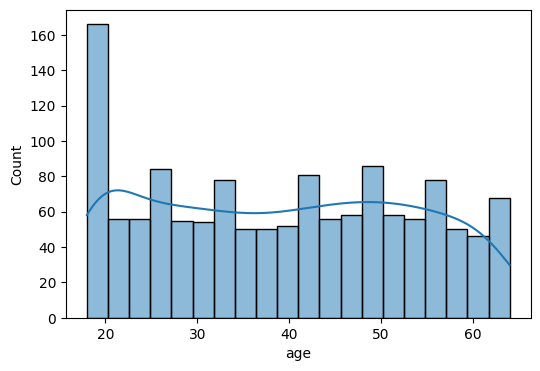

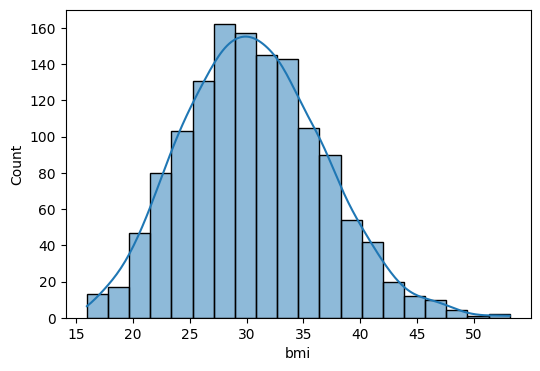

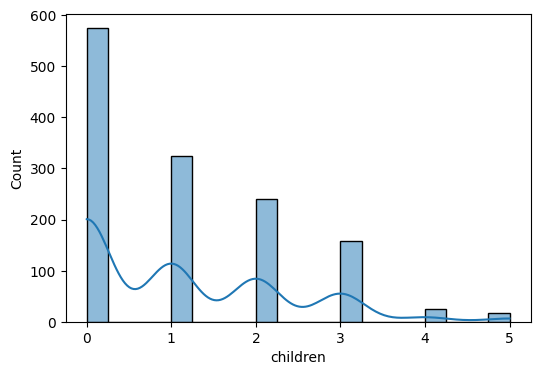

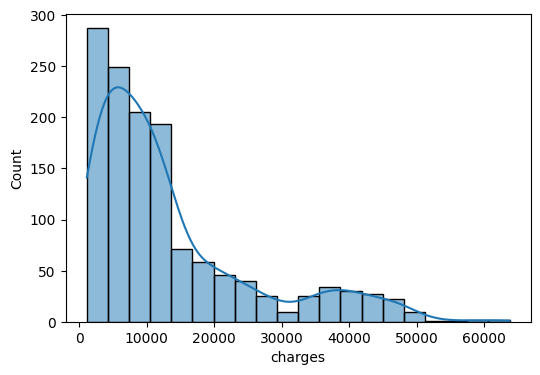

In [11]:
for col in numeric_columns:
  plt.figure(figsize=(6,4))
  sns.histplot(df[col],bins=20,kde=True)
  plt.xlabel(col)
  plt.show()

<Axes: xlabel='children', ylabel='count'>

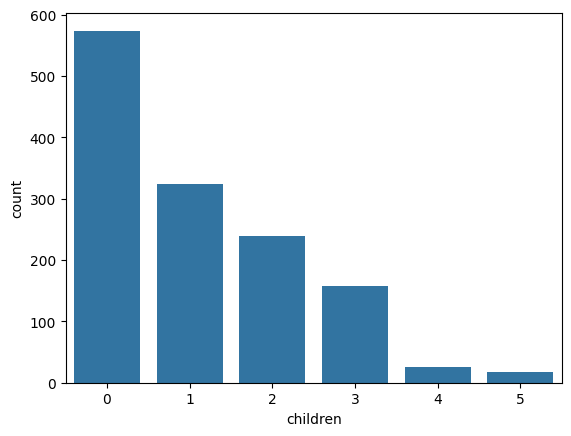

In [12]:
sns.countplot(x=df['children'])

<Axes: xlabel='sex', ylabel='count'>

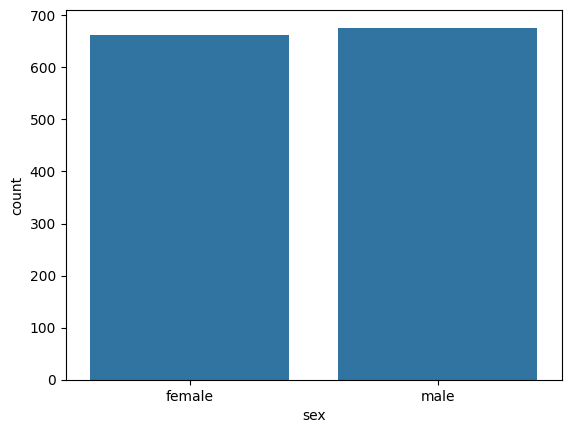

In [13]:
sns.countplot(x=df['sex'])

<Axes: xlabel='smoker', ylabel='count'>

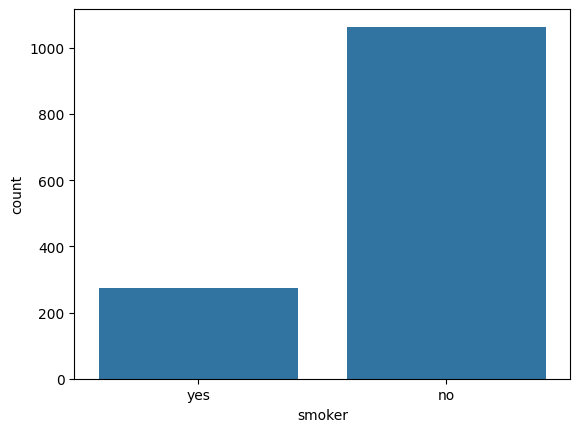

In [14]:
sns.countplot(x=df['smoker'])

Thus we can say that the skewness in charges coming due to 'smokers'
, 'children' ; The operations and analysis till now was exploratory data analysis


In [15]:
# Now we will see output and input together

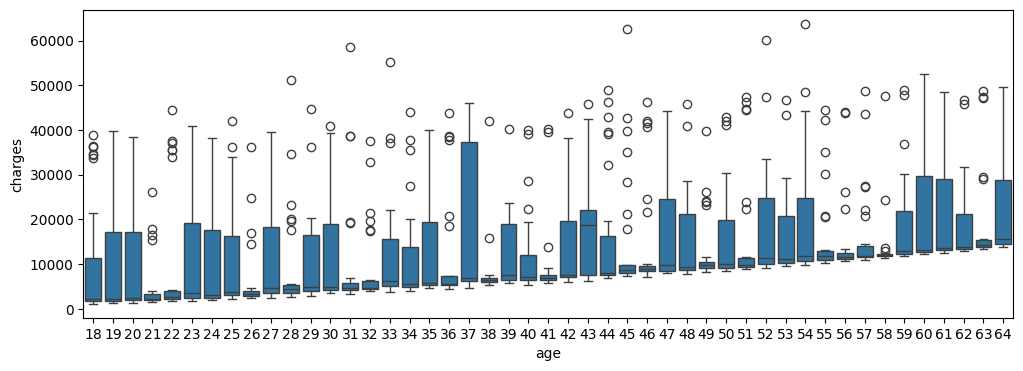

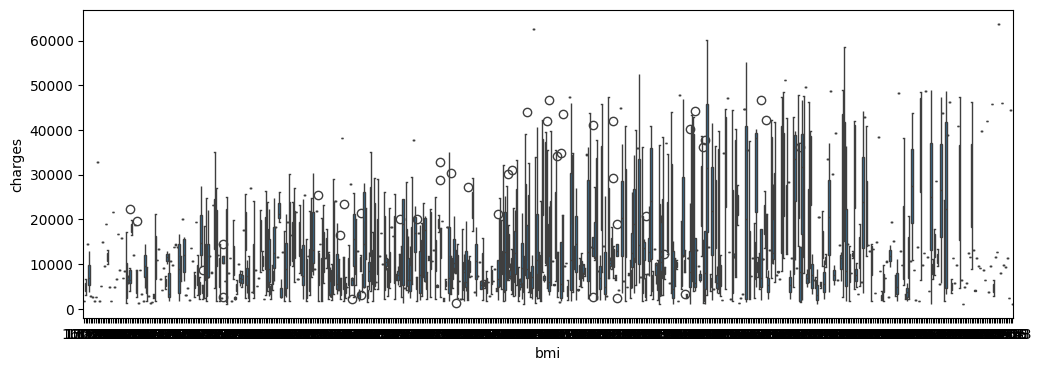

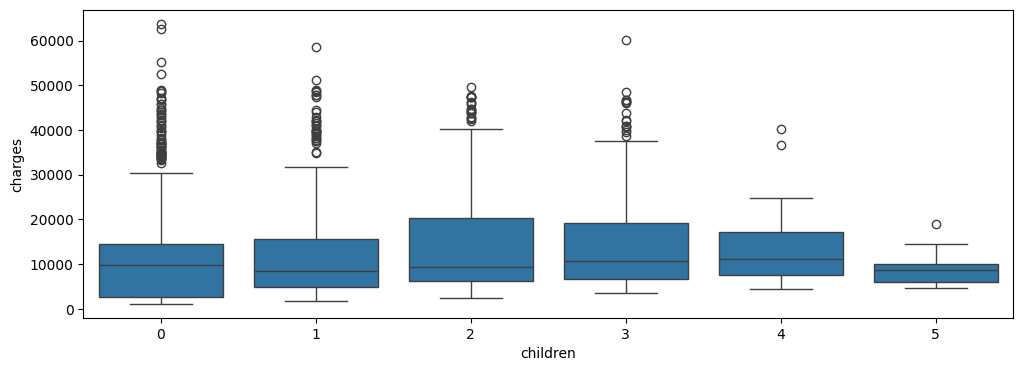

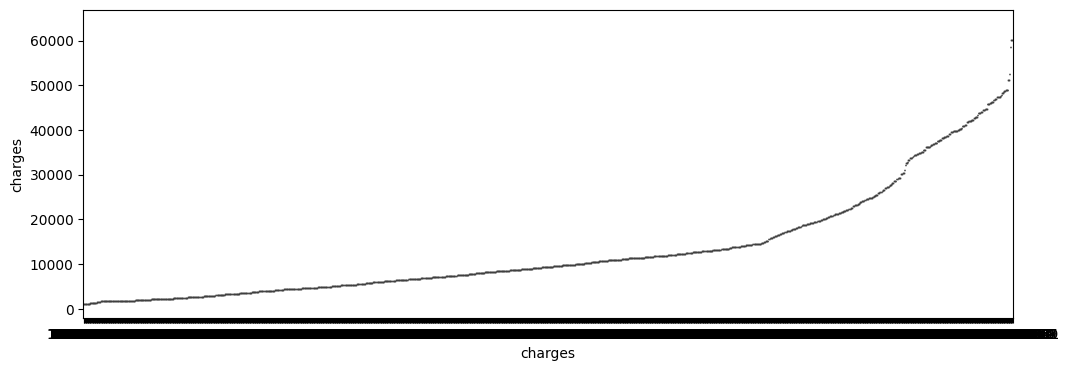

In [16]:
# Kyuki hame kai shaare inputs ke saath compare krrna hai isliye ham loop use krrenge

for col in numeric_columns:
  plt.figure(figsize=(12 ,4))
  sns.boxplot(x=df[col],y=df['charges'])
  plt.xlabel(col)
  plt.show()

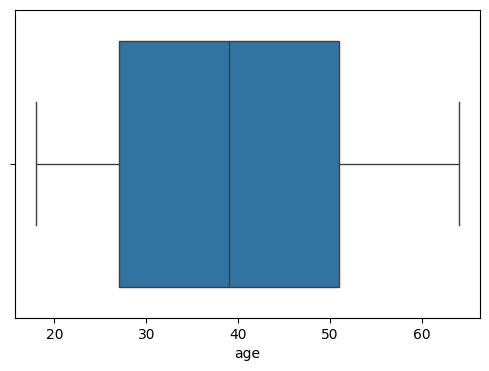

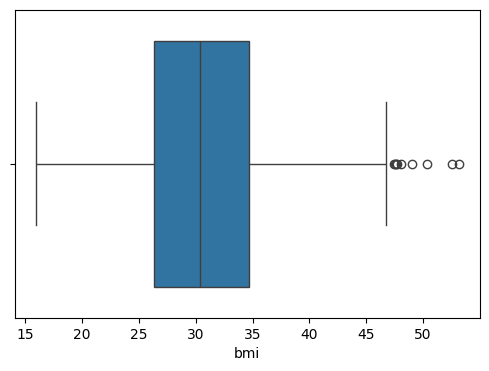

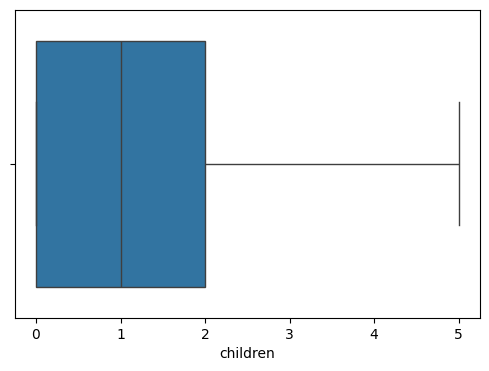

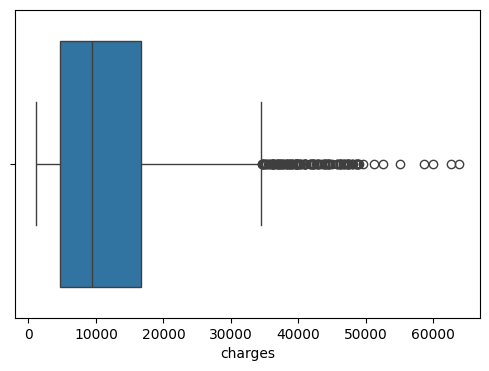

In [17]:
for col in numeric_columns:
  plt.figure(figsize=(6,4))
  sns.boxplot(x=df[col])
  plt.xlabel(col)
  plt.show()

<Axes: >

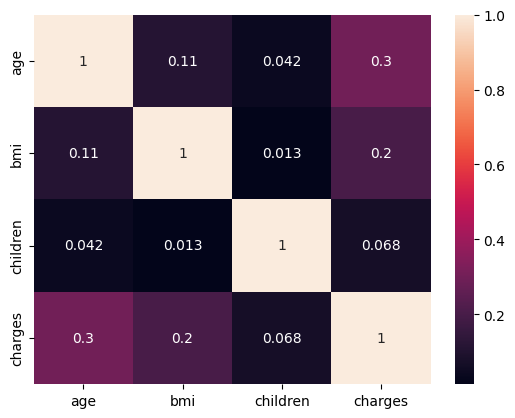

In [18]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

# Data cleaning and preprocessing



In [19]:
df_cleaned =df.copy()

In [20]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [21]:
df_cleaned.shape

(1338, 7)

In [22]:
df_cleaned.drop_duplicates(inplace=True)

In [23]:
df_cleaned.shape

(1337, 7)

In [24]:
df_cleaned.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [25]:
df_cleaned.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [26]:
df_cleaned['sex'].value_counts()

,count
sex,
male,675
female,662


In [27]:
# curly braces cause we are dealing the dataframe
df_cleaned['sex']=df_cleaned['sex'].map({'male':0,'female':1})

In [28]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [29]:
df_cleaned['smoker'].value_counts()


,count
smoker,
no,1063
yes,274


In [30]:
df_cleaned['smoker']=df_cleaned['smoker'].map({'no':0,'yes':1})

In [31]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [32]:
df_cleaned.rename(columns={
    'sex':'is_female',
    'smoker':'is_smoker'
},inplace=True)

In [33]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [34]:
df_cleaned['region'].value_counts()

,count
region,
southeast,364
southwest,325
northwest,324
northeast,324


In [35]:
# one-hot encoding
df_cleaned = pd.get_dummies(df_cleaned, columns=['region'], drop_first=True)

In [36]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


In [37]:
df_cleaned=df_cleaned.astype(int)

In [38]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0


# Feature Engineering and  extraction

<Axes: xlabel='bmi', ylabel='Count'>

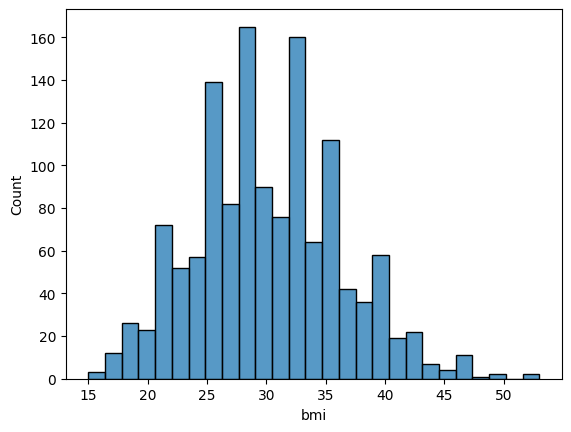

In [39]:
# Underweight (<18.5), Normal weight (18.5–24.9), and Overweight (25–29.9)
sns.histplot(df_cleaned['bmi'])

In [40]:
df_cleaned['bmi_category']=pd.cut(
    df_cleaned['bmi'] ,
    bins=[0,18.5,25,30,np.inf],
    labels=['underweight','normal','overweight','obeseity']
)

In [41]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,1,overweight
1,18,0,33,1,0,1725,0,1,0,obeseity
2,28,0,33,3,0,4449,0,1,0,obeseity
3,33,0,22,0,0,21984,1,0,0,normal
4,32,0,28,0,0,3866,1,0,0,overweight


In [42]:
df_cleaned = pd.get_dummies(df_cleaned, columns=['bmi_category'], drop_first=True)


In [43]:
df_cleaned=df_cleaned.astype(int)

In [44]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_obeseity
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0


# Featue Scaling

In [45]:
# some model's depend on wights like knn
# linear,logistic regression doesn't depend on weghts
#  wha pe apne ko Feature scaling krni padegi

# AGe aur Bmi Standard scaling pe lgeag

In [46]:
df_cleaned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_normal', 'bmi_category_overweight',
       'bmi_category_obeseity'],
      dtype='object')

In [47]:
from sklearn.preprocessing import StandardScaler
cols = ['age','bmi','children']
scaler = StandardScaler()

df_cleaned[cols] = scaler.fit_transform(df_cleaned[cols])

In [48]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_obeseity
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,0,1,0


In [49]:
# wanna checck my correlation wiith my target variable

In [50]:
from scipy.stats import pearsonr

selected_features = ['age', 'bmi', 'children', 'is_female', 'is_smoker',
                     'region_northwest','region_southwest','region_southeast',
                     'bmi_category_normal',	'bmi_category_overweight'	,'bmi_category_obeseity']

correlation = {
    feature : pearsonr(df_cleaned[feature], df_cleaned['charges'])[0]
    for feature in selected_features
}
correlation_df = pd.DataFrame(list(correlation.items()), columns=['feature', 'correlation'])
correlation_df = correlation_df.sort_values(by='correlation', ascending=True)

print(correlation_df)

                    feature  correlation
8       bmi_category_normal    -0.121586
9   bmi_category_overweight    -0.081555
3                 is_female    -0.058046
6          region_southwest    -0.043637
5          region_northwest    -0.038695
2                  children     0.067390
7          region_southeast     0.073577
10    bmi_category_obeseity     0.189515
1                       bmi     0.196236
0                       age     0.298309
4                 is_smoker     0.787234


In [50]:
# We will pick the object having low correlation bbetween  0.10 and 0.20 ,
# we will add them in the model and if the accuracy > 80 then it's good otherwise we will have to reove it

# ALso try making pair of objects can help boosting/increasing the accuracy

In [50]:
# Chi-square test ( select all ccategoric features)

In [56]:
cat_features = [
    'is_female','is_smoker','region_northwest',
    'region_southwest','region_southeast','bmi_category_normal',
    'bmi_category_overweight','bmi_category_obeseity'
]

In [50]:
# Isme ham target variable ko comare krte hai different categorical data se ,
# But here our target variable is continuos variable thus we will create bins and then compare it

In [57]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.2

df_cleaned['charges_bin'] = pd.qcut(df_cleaned['charges'],q=4,labels=False)
chi2_results = {}

for feature in cat_features:
    contingency_table = pd.crosstab(df_cleaned[feature], df_cleaned['charges_bin'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    decision = "Reject null hypothesis" if p < alpha else "Fail to reject null hypothesis"
    chi2_results[feature] = {'chi2': chi2, 'p_value': p, 'decision': decision}

In [58]:
chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value', ascending=True)

print(chi2_df)

                               chi2   p_value                        decision
is_smoker                848.219178       0.0          Reject null hypothesis
region_southeast          15.998167  0.001135          Reject null hypothesis
is_female                 10.258784   0.01649          Reject null hypothesis
bmi_category_obeseity      9.737965   0.02093          Reject null hypothesis
region_southwest           5.091893  0.165191          Reject null hypothesis
bmi_category_normal        4.771699  0.189298          Reject null hypothesis
bmi_category_overweight    4.450807   0.21672  Fail to reject null hypothesis
region_northwest            1.13424  0.768815  Fail to reject null hypothesis


In [61]:
final_df = df_cleaned[['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges','region_southeast','bmi_category_obeseity']]

In [62]:
final_df


,age,is_female,bmi,children,is_smoker,charges,region_southeast,bmi_category_obeseity
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0
1,-1.511647,0,0.462463,-0.079442,0,1725,1,1
2,-0.799350,0,0.462463,1.580143,0,4449,1,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,0,0
...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,0,10600,0,0
1334,-1.511647,1,0.135659,-0.909234,0,2205,0,1
1335,-1.511647,1,0.952670,-0.909234,0,1629,1,1
1336,-1.297958,1,-0.844753,-0.909234,0,2007,0,0
